In [3]:
import treecorr
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
#import fitsio
from astropy.table import Table
#import csv 
import pandas as pd
import polars as pl

try:
    plt.style.use('/home/dy9683/cosmic-shear/cosmic-shear-with-spec-z/paperfigs.mplstyle')
except Exception as e:
    print(f'Error: {e}')
    # print(f"Could not find style file paperfigs.mplstyle")

# Load Catalog

DECADE NGC and SGC Matched from Jared

In [1]:
decade_north = '/scratch/gpfs/js1998/matched_catalogs/decade_ngc_matched.csv'

In [2]:
decade_south = '/scratch/gpfs/js1998/matched_catalogs/decade_sgc_matched.csv'

In [4]:
file_path_north = decade_north
decade_north_catalog = pl.scan_csv(file_path_north).filter(pl.col('lensing_match') == 1).collect()

In [5]:
file_path_south = decade_south
decade_south_catalog = pl.scan_csv(file_path_south).filter(pl.col('lensing_match') == 1).collect()

In [6]:
decade_combined_catalog = pl.concat([decade_north_catalog, decade_south_catalog])

In [7]:
decade_combined_catalog

,TARGETID,SURVEY,PROGRAM,TILEID,LASTNIGHT,Z_BEST,Z_CONF,ZERR_BEST,ZWARN_BEST,SPECTYPE_BEST,SUBTYPE_BEST,CHI2_BEST,DELTACHI2_BEST,PETAL_LOC,FIBER,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,DESINAME,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MIN_MJD,MAX_MJD,MEAN_MJD,GOOD_SPEC,EFFTIME_SPEC,ZCAT_NSPEC,ZCAT_PRIMARY,SV_NSPEC,SV_PRIMARY,MAIN_NSPEC,MAIN_PRIMARY,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV1_SCND_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV2_SCND_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV3_SCND_TARGET,lensing_ra,lensing_dec,e1,e2,lensing_weight,R11,R22,lensing_match
i64,i64,str,str,i64,i64,f64,i64,f64,i64,str,str,f64,f64,i64,i64,i64,f64,f64,str,str,f64,f64,i64,i64,f64,i64,i64,f64,f64,f64,bool,f64,i64,bool,i64,bool,i64,bool,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64
80697,-417711488,"""b'main'""","""b'backup'""",41771,20211218,1.356062,0,0.000236,2049,"""b'GALAXY'""",null,6700.292,12.110747,1,697,1026,130.854114,-11.355153,"""b'DESI J130.8541-11.3551'""","""b'SKY'""",224.25804,-318.42374,0,2,1123.432,2,1,59566.409746,59567.41364,59566.911693,false,125.00263,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,130.854241,-11.354927,0.147408,0.020858,7.422119,0.453932,-0.065216,1
80797,-417711255,"""b'main'""","""b'backup'""",41771,20211218,1.16603,0,0.000114,2053,"""b'GALAXY'""",null,7046.434,5.338035,1,797,1026,130.909691,-10.803301,"""b'DESI J130.9096-10.8033'""","""b'SKY'""",206.51672,-175.4416,0,2,1123.432,2,1,59566.409746,59567.41364,59566.911693,false,134.83508,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,130.909562,-10.803496,0.049139,-0.285746,5.336765,-0.207945,0.01785,1
81645,-417713483,"""b'main'""","""b'backup'""",41771,20211218,1.133182,0,0.000033,1,"""b'GALAXY'""",null,7351.8774,290.0763,3,1645,2,130.162376,-9.817843,"""b'DESI J130.1623-09.8178'""","""b'SKY'""",398.24078,69.89453,0,2,1123.432,2,1,59566.409746,59567.41364,59566.911693,false,913.755,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,130.16223,-9.817851,0.183636,0.481722,23.249027,1.150082,0.804988,1
84659,-417719086,"""b'main'""","""b'backup'""",41771,20211218,0.478711,0,0.00034,1,"""b'QSO'""","""b'LOZ'""",6784.2974,148.73563,9,4659,2,132.123514,-10.653513,"""b'DESI J132.1235-10.6535'""","""b'SKY'""",-87.93246,-136.8609,0,2,1123.432,2,1,59566.409746,59567.41364,59566.911693,false,100.503525,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,132.123256,-10.653573,-0.218062,-0.07905,23.787299,0.992428,1.009174,1
132149,-417774088,"""b'main'""","""b'backup'""",41777,20220101,0.672422,0,0.000136,2053,"""b'GALAXY'""",null,7241.9624,8.889104,4,2149,1026,138.017101,-11.289676,"""b'DESI J138.0171-11.2896'""","""b'SKY'""",68.40202,147.69345,0,2,929.5666,2,1,59566.436373,59581.378986,59573.90768,false,136.54378,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,138.017203,-11.28987,0.247391,-0.087481,8.992332,0.248999,0.39242,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
117130497,39627737635227022,"""b'sv1'""","""b'bright'""",80639,20210224,0.444159,3,0.000005,0,"""b'GALAXY'""",null,14540.068,13576.82,9,4997,0,73.054912,-1.920322,"""b'DESI J073.0549-01.9203'""","""b'TGT'""",-136.53491,-202.87003,2000,12,3298.11,6,1,59225.170679,59270.116731,59250.066269,true,409.45535,1,true,1,true,0,false,0,0,0,0,0,1152921504690733137,131074,0,0,0,0,0,0,0,0,0,0,73.054904,-1.920325,0.005807,-0.004596,24.010139,0.746636,0.721392,1
117130499,39627737635229667,"""b'sv1'""","""b'bright'""",80639,20210224,0.368322,3,0.000017,0,"""b'GALAXY'""",null,8238.486,581.8472,9,4999,0,73.163792,-1.915007,"""b'DESI J073.1637-01.9150'""","""b'TGT'""",-163.74916,-202.03836,2000,12,3298.11,6,1,59225.170679,59270.116731,59250.066269,true,393.63666,1,true,1,true,0,false,0,0,0,0,0,1152921

In [8]:
ra = decade_combined_catalog['TARGET_RA']
dec = decade_combined_catalog['TARGET_DEC']
g1 = decade_combined_catalog['e1'] 
g2 = decade_combined_catalog['e2']
z = decade_combined_catalog['Z_BEST']

# Plots

In [9]:
print(f'Number of sources: {len(decade_combined_catalog):,}')

Number of sources: 10,816,067


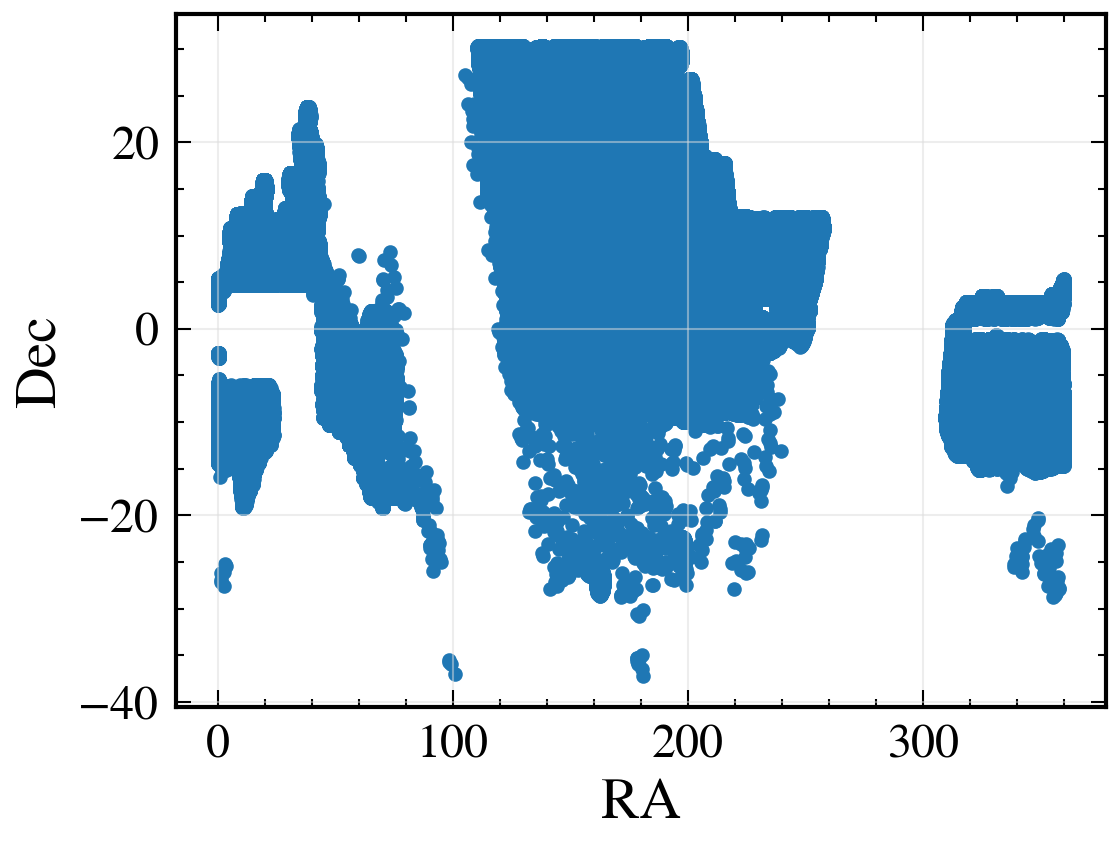

In [10]:
# ra v dec
fig, ax = plt.subplots(figsize = (8,6))
ax.scatter(ra, dec)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
#ax.set_xlim(0, 360)
#ax.set_ylim(-30, 30)
plt.show()

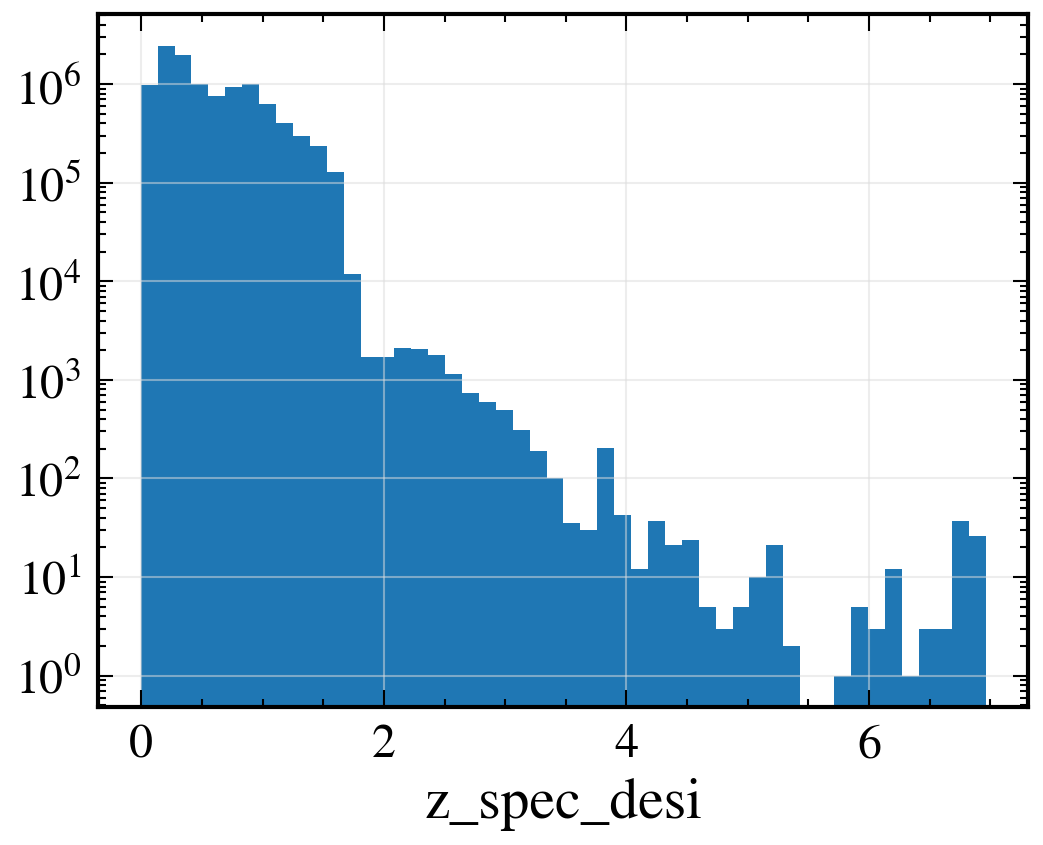

In [11]:
# histogram of redshifts
fig, ax = plt.subplots(figsize = (8,6))
ax.hist(z, bins = 50 , density = False)
ax.set_xlabel("z_spec_desi")
ax.set_yscale('log')
plt.show()

# TreeCorr Calculations

https://rmjarvis.github.io/TreeCorr/_build/html/gg.html

In [12]:
cat = treecorr.Catalog(ra=ra, dec=dec, g1=g1, g2=g2, ra_units='degrees', dec_units='degrees')
gg = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg.process(cat)

r = np.exp(gg.meanlogr)

# correlation functions
#xi_+
xip = gg.xip
# # xi_-
xim = gg.xim

#calculate variance
sig_xip = np.sqrt(gg.varxip)
sig_xim = np.sqrt(gg.varxim)

# $\xi_{+/-}$ Plot

In [13]:
xip

array([-3.20053694e-05, -4.25651576e-05,  4.92048362e-05,  5.54146650e-05,
        9.11118968e-06,  1.66890795e-05, -1.36105868e-05,  1.12979569e-05,
        1.79000326e-05,  2.88288217e-06, -5.48526927e-06,  4.23062167e-06,
        6.04171263e-06,  8.25922210e-06, -2.83658156e-07,  2.55072245e-06,
        2.34029597e-06,  4.69831314e-08,  1.29132138e-09,  1.82163501e-06])

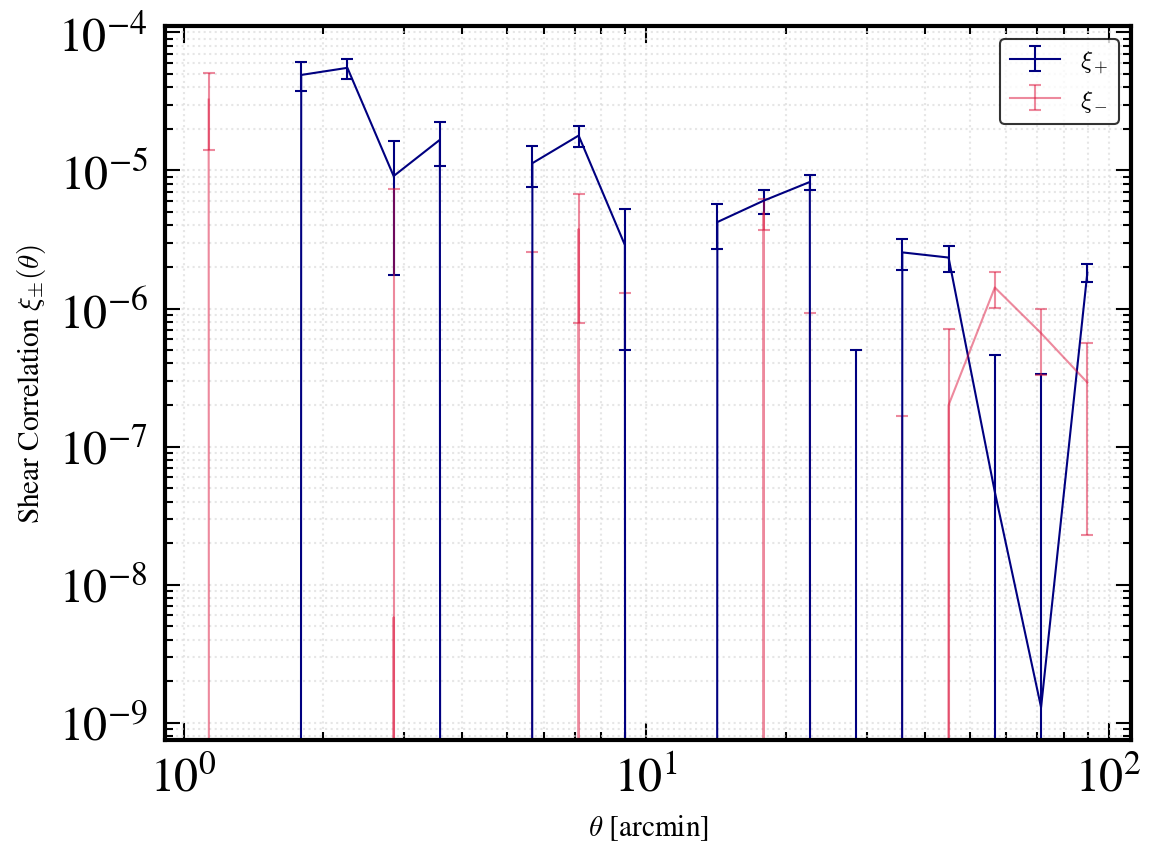

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r, xip, yerr=sig_xip, label=r'$\xi_+$', color='navy', capsize=3)
ax.errorbar(r, xim, yerr=sig_xim, label=r'$\xi_-$', color='crimson', capsize=3, alpha = 0.5)

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{\pm}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

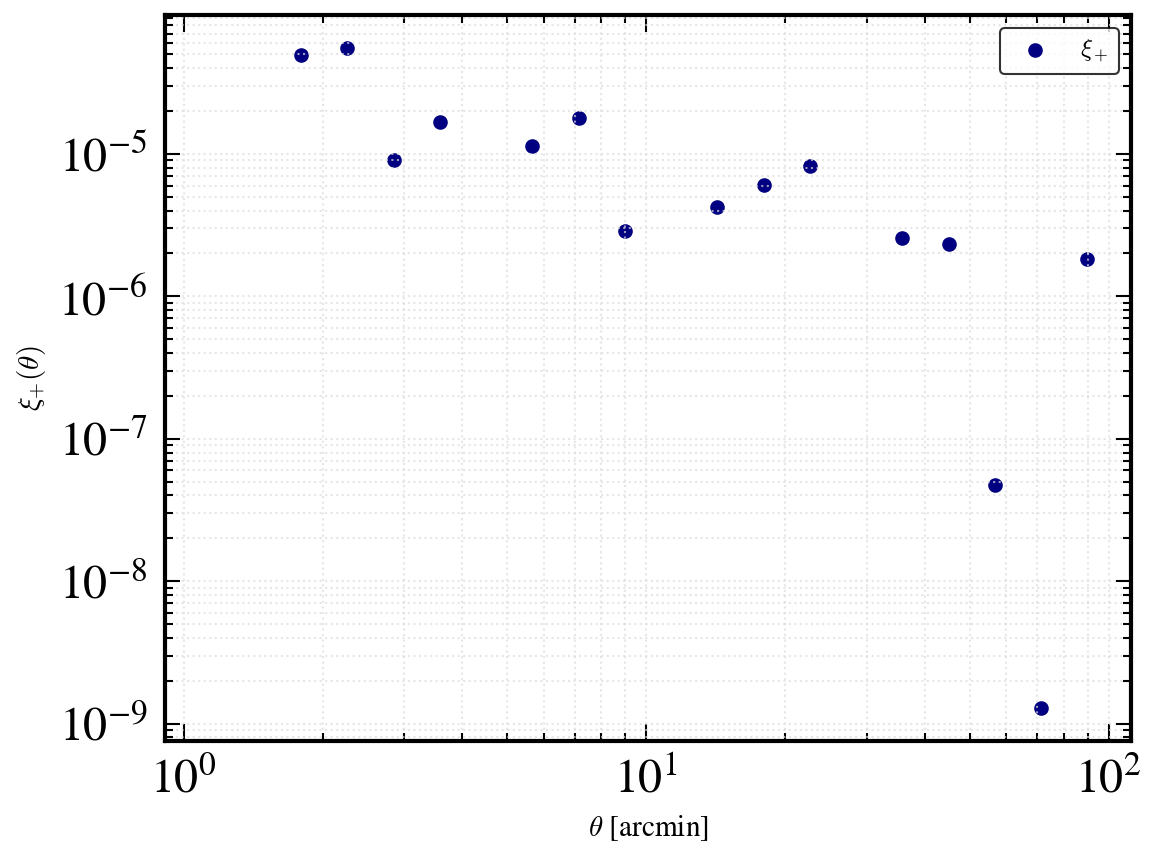

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(r, xip, label=r'$\xi_+$', color='navy')

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'$\xi_{+}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()